# Donchian 单股验证：000333 美的
目标：先验证中文显示 + 数据加载。
后续再加通道与模拟。

2022-11-01 00:00:00 -> 2026-08-14 00:00:00 共920行
             open   high    low  close      volume
date                                              
2022-11-01  40.58  41.60  40.09  41.60  48067142.0
2022-11-02  41.40  42.60  41.22  42.08  38019949.0
2022-11-03  41.80  41.87  41.20  41.58  28853488.0


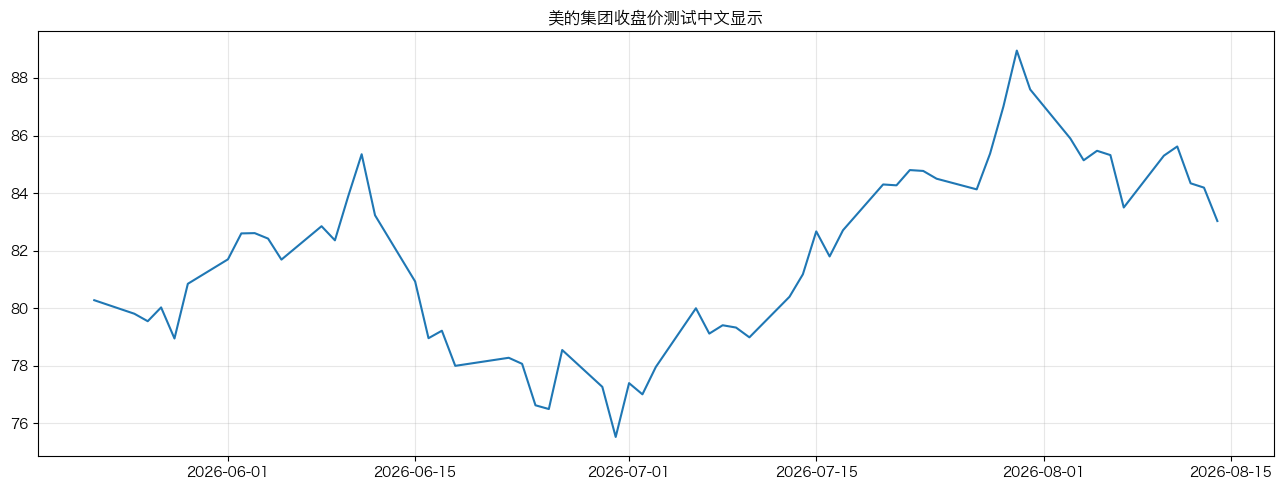

In [ ]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Hiragino Sans GB', 'STHeiti', 'Songti SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
_ROOT = os.getcwd()
for _ in range(4):
    if os.path.exists(os.path.join(_ROOT, 'data', '000333_market.csv')): break
    _ROOT = os.path.dirname(_ROOT)
os.chdir(_ROOT)
CODE = '000333'
START = pd.Timestamp('2023-01-01')
df = pd.read_csv(f'data/{CODE}_market.csv', index_col='date', parse_dates=True).sort_index()
print(df.index.min(), '->', df.index.max(), f'共{len(df)}行')
print(df.head(3).to_string())
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index[-60:], df['close'].tail(60))
ax.set_title('美的集团收盘价测试中文显示')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

            close  dc_high  dc_low
date                              
2023-01-12  54.77     55.8   51.02
2023-01-13  55.95     55.8   51.02
2023-01-16  57.70     56.0   51.23
            close  dc_high  dc_low
date                              
2023-05-31  51.33    58.45   51.79
2023-06-01  48.89    58.45   51.10
2023-06-02  51.80    57.49   48.53


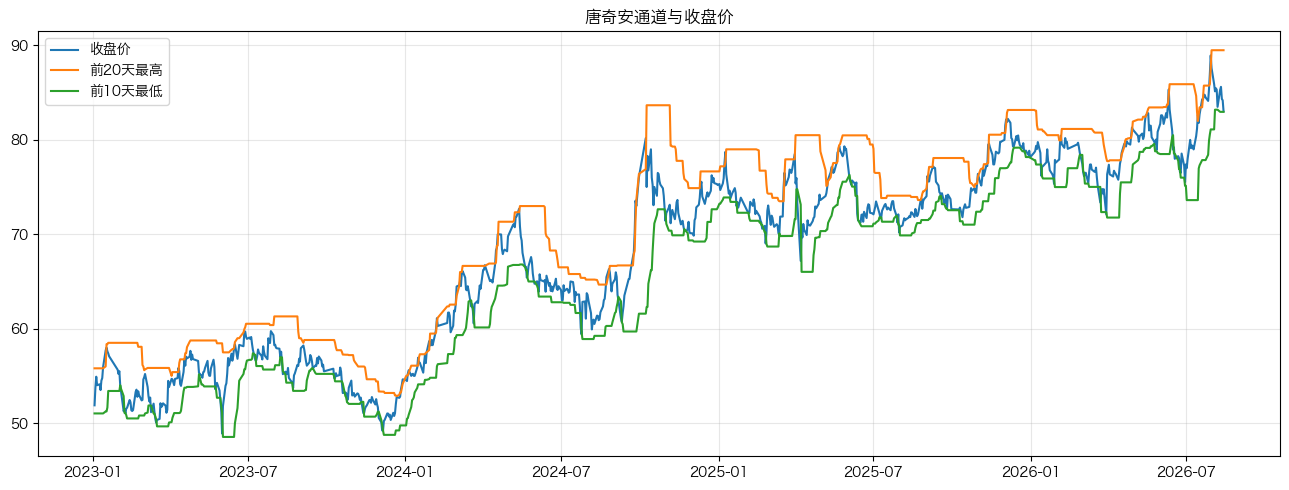

In [ ]:
df['dc_high'] = df['high'].rolling(20).max().shift(1)
df['dc_low'] = df['low'].rolling(10).min().shift(1)
print(df.loc['2023-01-12':'2023-01-16', ['close','dc_high','dc_low']].to_string())
print(df.loc['2023-05-31':'2023-06-02', ['close','dc_high','dc_low']].to_string())
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['2023-01-01':].index, df['2023-01-01':]['close'], label='收盘价')
ax.plot(df['2023-01-01':].index, df['2023-01-01':]['dc_high'], label='前20天最高')
ax.plot(df['2023-01-01':].index, df['2023-01-01':]['dc_low'], label='前10天最低')
ax.legend(); ax.grid(alpha=0.3); ax.set_title('唐奇安通道与收盘价')
plt.tight_layout(); plt.show()

In [ ]:
COMM, TAX = 0.0003, 0.0005
cash, shares, trades = 1_000_000.0, 0, []
sub = df[df.index >= START].copy()
for d, r in sub.iterrows():
    p, hi, lo = r['close'], r['dc_high'], r['dc_low']
    if shares == 0 and pd.notna(hi) and p > hi:
        n = int(cash / (p * (1 + COMM)) // 100 * 100)
        cash, shares = cash - n * p * (1 + COMM), n
        trades.append((d, '买入', p)) if n > 0 else None
    elif shares > 0 and pd.notna(lo) and p < lo:
        cash = cash + shares * p * (1 - COMM - TAX)
        trades.append((d, '卖出', p)); shares = 0
print(f'信号{len(trades)}次，首轮:', trades[0], '->', trades[1])
import plotly.graph_objects as go
buys = [t for t in trades if t[1] == '买入']
sells = [t for t in trades if t[1] == '卖出']
fig = go.Figure()
fig.add_trace(go.Scatter(x=sub.index, y=sub['close'], mode='lines', name='收盘价', hovertemplate='日期:%{x|%Y-%m-%d}<br>价格:%{y:.2f}<extra></extra>'))
fig.add_trace(go.Scatter(x=[t[0] for t in buys], y=[t[2] for t in buys], mode='markers', marker=dict(color='red', symbol='triangle-up', size=10), name='买入', hovertemplate='买入<br>日期:%{x|%Y-%m-%d}<br>价格:%{y:.2f}<extra></extra>'))
fig.add_trace(go.Scatter(x=[t[0] for t in sells], y=[t[2] for t in sells], mode='markers', marker=dict(color='green', symbol='triangle-down', size=10), name='卖出', hovertemplate='卖出<br>日期:%{x|%Y-%m-%d}<br>价格:%{y:.2f}<extra></extra>'))
fig.update_layout(title='纯唐奇安买卖点（悬停看日期价格）', height=500, hovermode='closest')
fig.show()

信号29次，首轮: (Timestamp('2023-01-13 00:00:00'), '买入', np.float64(55.95)) -> (Timestamp('2023-02-02 00:00:00'), '卖出', np.float64(53.96))
